# **1. Perkenalan Dataset**


Dataset ini awalnya berasal dari Institut Nasional Penyakit Diabetes, Pencernaan, dan Ginjal. Tujuan dari kumpulan data ini adalah untuk memprediksi secara diagnostik apakah seorang pasien menderita diabetes atau tidak, berdasarkan beberapa pengukuran diagnostik yang tercantum dalam kumpulan data tersebut. Ada beberapa batasan yang diterapkan dalam pemilihan contoh-contoh data ini dari basis data yang lebih besar. Secara khusus, semua pasien dalam kumpulan data ini adalah perempuan berusia minimal 21 tahun yang berasal dari suku Indian Pima

1. **Sumber Dataset**:  
   Dataset  diperoleh dari berbagai public repositories *Kaggle*,
   untuk sourcenya bisa melalui link: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database?resource=download

2. **Konten Dataset**:  
   Dataset terdiri dari beberapa variabel prediktor medis dan satu variabel target, yaitu Hasil. Variabel prediktor meliputi jumlah kehamilan yang pernah dialami pasien, indeks massa tubuh (BMI), kadar insulin, usia, dan sebagainya.

  

# **2. Import Library**

Pada tahap ini, Import librari yang dibutuhkan dalam proses analisis data

In [ ]:
#Type your code here
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import statsmodels.api as sm
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

# **3. Memuat Dataset**

Pada tahap ini, Dataset dimuat dalam format CSV, menggunakan pandas untuk memuat dan membaca data dalam bentuk dataframe.

In [ ]:
#Type your code here
df=pd.read_csv('diabetes.csv')
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [ ]:
#Type your code here
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.duplicated().sum()

np.int64(0)

/tmp/ipykernel_1197/218699559.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='Outcome',palette='Set2')


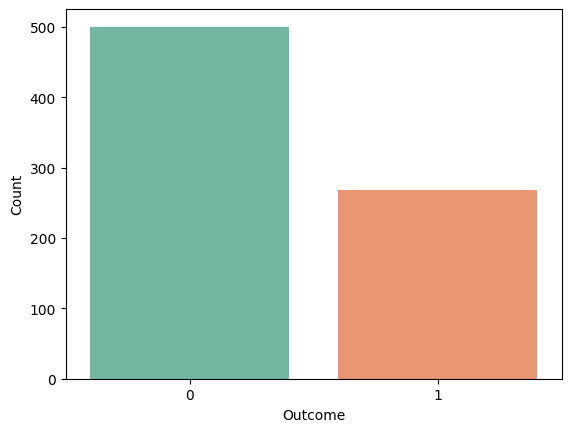

In [ ]:
sns.countplot(data=df,x='Outcome',palette='Set2')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

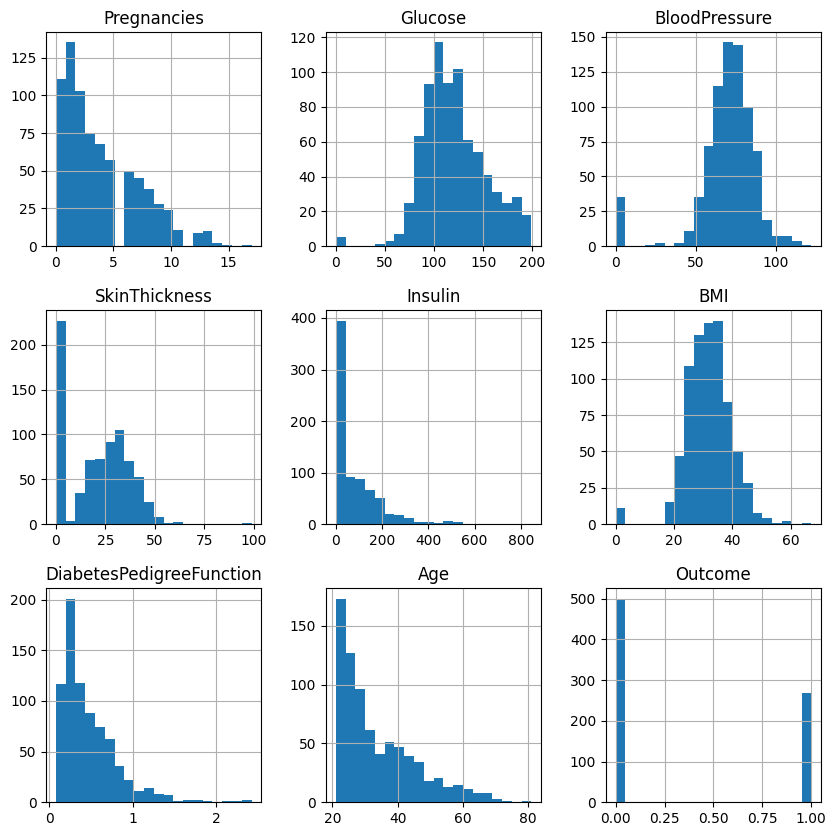

In [ ]:
df.hist(figsize=(10,10),bins=20)
plt.show()

In [ ]:
df.corr(numeric_only=True)['Outcome']


,Outcome
Pregnancies,0.221898
Glucose,0.466581
BloodPressure,0.065068
SkinThickness,0.074752
Insulin,0.130548
BMI,0.292695
DiabetesPedigreeFunction,0.173844
Age,0.238356
Outcome,1.000000


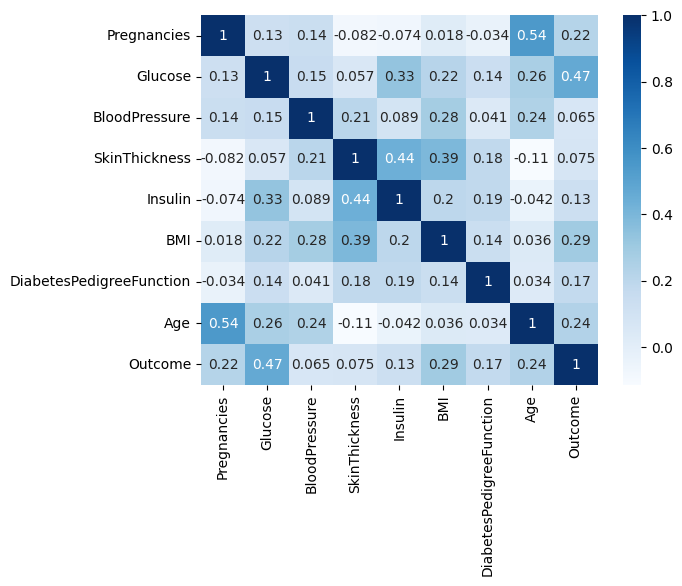

In [ ]:
sns.heatmap(df.corr(),annot=True,cmap='Blues')
plt.show()

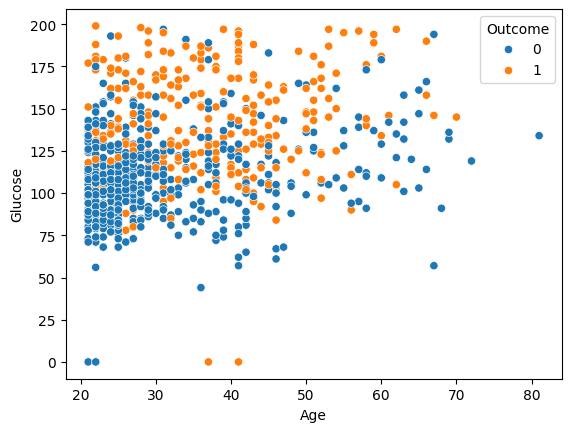

In [ ]:
sns.scatterplot(data=df,x='Age',y='Glucose',hue='Outcome')
plt.show()

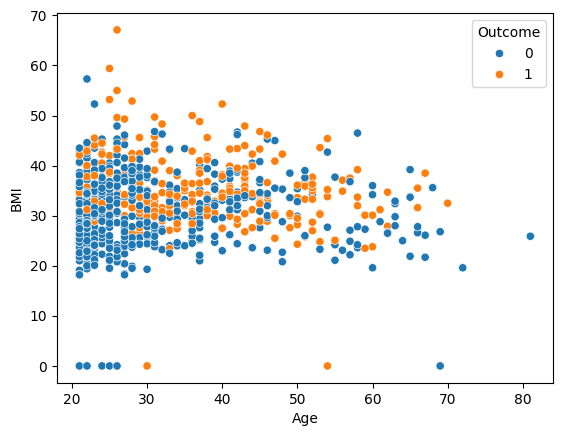

In [ ]:
sns.scatterplot(data=df,x='Age',y='BMI',hue='Outcome')
plt.show()

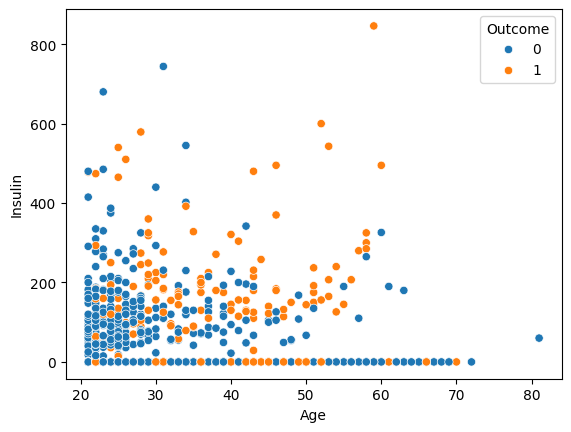

In [ ]:
sns.scatterplot(data=df,x='Age',y='Insulin',hue='Outcome')
plt.show()


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']].isin([0]).sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [ ]:
cul_zero=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in cul_zero:
    df[col]=df[col].replace(0,np.nan)


In [ ]:
imputer = SimpleImputer(strategy="median")
df[cul_zero]= imputer.fit_transform(df[cul_zero])

In [ ]:
X = df.drop('Outcome',axis=1)
y = df['Outcome']

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.25,
                                                       random_state=42,shuffle=True,
                                                       stratify=y)

In [ ]:
scale = StandardScaler()
X_train_stand = scale.fit_transform(X_train)
X_test_stand = scale.transform(X_test)


# **6. Modeling**

Membangun model dengan data yang sudah dibersihkan

Menemukan model yang terbaik dengan menggunkan berbagai parameter yang digunakan dan juga menggunakan GridSearchCV dalam membantu mencari parameter yang terbaik

In [ ]:
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale','auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly'],
    'degree': [2, 3]
}
svc = SVC()
grid = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_stand, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)

Best parameters: {'C': 10, 'degree': 2, 'gamma': 0.001, 'kernel': 'rbf'}
Best cross-validation score: 0.7847076461769115


In [ ]:
svm_model = SVC( kernel='rbf',class_weight='balanced',random_state=True,C=10,gamma=0.001)
svm_model.fit(X_train_stand,y_train)

SVC(C=10, class_weight='balanced', gamma=0.001, random_state=True)

In [ ]:
y_pred = svm_model.predict(X_test_stand)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.7552083333333334


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.78      0.81       125
           1       0.64      0.70      0.67        67

    accuracy                           0.76       192
   macro avg       0.73      0.74      0.74       192
weighted avg       0.76      0.76      0.76       192

